Install & Import Everything

In [ ]:
# ============================================================
# BLOCK 1: INSTALL AND IMPORT
# ============================================================
# WHY: We need specific libraries for data handling,
#      visualisation, ML models, imbalance fixing, and metrics.
#      imbalanced-learn gives us SMOTE.
# ============================================================

# Install imbalanced-learn (not pre-installed in all environments)
!pip install imbalanced-learn --quiet

# ── Data handling ────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Preprocessing ────────────────────────────────────────────
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    MinMaxScaler
)

# ── Feature selection ────────────────────────────────────────
from sklearn.feature_selection import RFE

# ── Clustering ───────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Train-Test Split ─────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# ── Imbalance fix ────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Regression Models ────────────────────────────────────────
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble        import RandomForestClassifier, RandomForestRegressor
from sklearn.svm             import SVC, SVR
from sklearn.neighbors       import KNeighborsClassifier, KNeighborsRegressor

# ── Evaluation Metrics ───────────────────────────────────────
from sklearn.metrics import (
    # Regression
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    # Classification
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Settings ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Makes all plots look clean and consistent
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size']      = 11

print(" All libraries imported successfully.")
print("   You are ready to start building the pipeline.")

 All libraries imported successfully.
   You are ready to start building the pipeline.


 BLOCK 2 — Load Data & First Look

In [ ]:
# ============================================================
# BLOCK 2: LOAD DATA AND UNDERSTAND IT
# ============================================================
# WHY: Before touching anything, we must understand what we
#      have. This is called Data Understanding.
#      Never clean or model data you haven't looked at first.
# ============================================================

# ── Load the dataset ─────────────────────────────────────────

df = pd.read_csv('/content/StudentPerformanceFactors  data.csv')

# ── Basic information ─────────────────────────────────────────
print("=" * 55)
print("DATASET BASIC INFORMATION")
print("=" * 55)
print(f"  Rows (students)  : {df.shape[0]}")
print(f"  Columns(features): {df.shape[1]}")

# ── Column names and data types ───────────────────────────────
print("\n" + "=" * 55)
print("COLUMNS AND THEIR DATA TYPES")
print("=" * 55)
print(df.dtypes)

# ── First 5 rows ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("FIRST 5 ROWS OF DATA")
print("=" * 55)
print(df.head())

# ── Statistical summary ───────────────────────────────────────
print("\n" + "=" * 55)
print("STATISTICAL SUMMARY (numerical columns)")
print("=" * 55)
print(df.describe().round(2))

# ── Missing values ────────────────────────────────────────────
print("\n" + "=" * 55)
print("MISSING VALUES PER COLUMN")
print("=" * 55)
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)
missing_df   = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing Percent': missing_pct
})
# Show only columns that actually have missing values
print(missing_df[missing_df['Missing Count'] > 0])

# ── Unique values per column ──────────────────────────────────
print("\n" + "=" * 55)
print("UNIQUE VALUES PER CATEGORICAL COLUMN")
print("=" * 55)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n  {col}:")
    print(f"    Unique values : {df[col].unique()}")
    print(f"    Count         : {df[col].value_counts().to_dict()}")

DATASET BASIC INFORMATION
  Rows (students)  : 6607
  Columns(features): 20

COLUMNS AND THEIR DATA TYPES
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

FIRST 5 ROWS OF DATA
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                 

BLOCK 3 — EDA (Exploratory Data Analysis)

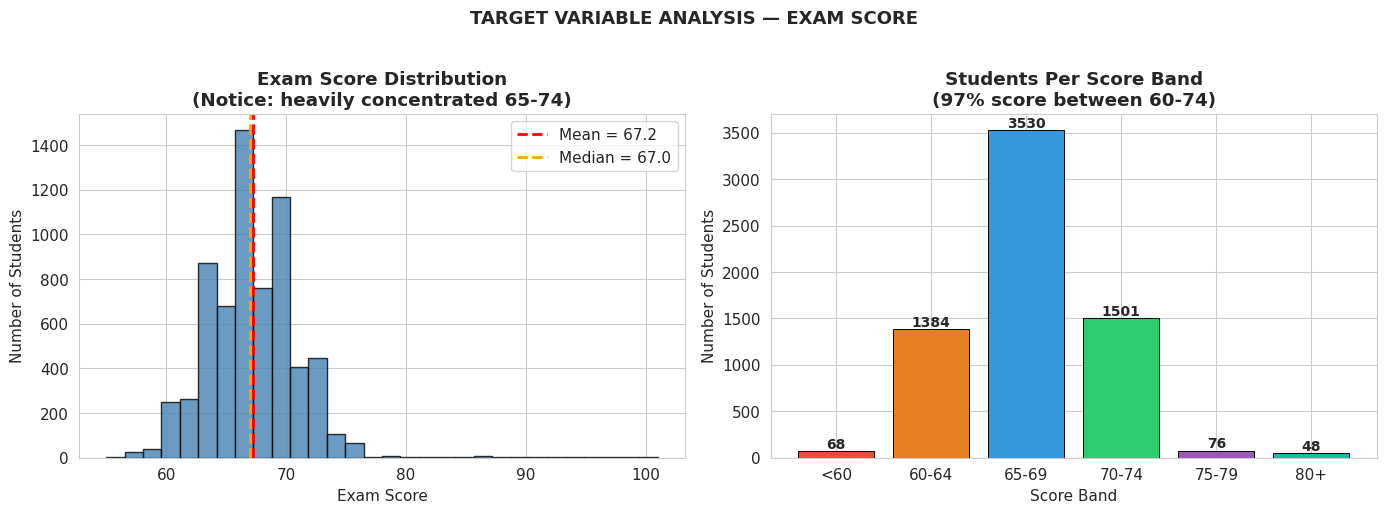


 KEY FINDING:
   97.1% of students score between 60 and 74
   Only 48 students score 80+
   This is CLASS IMBALANCE — we will fix it with SMOTE


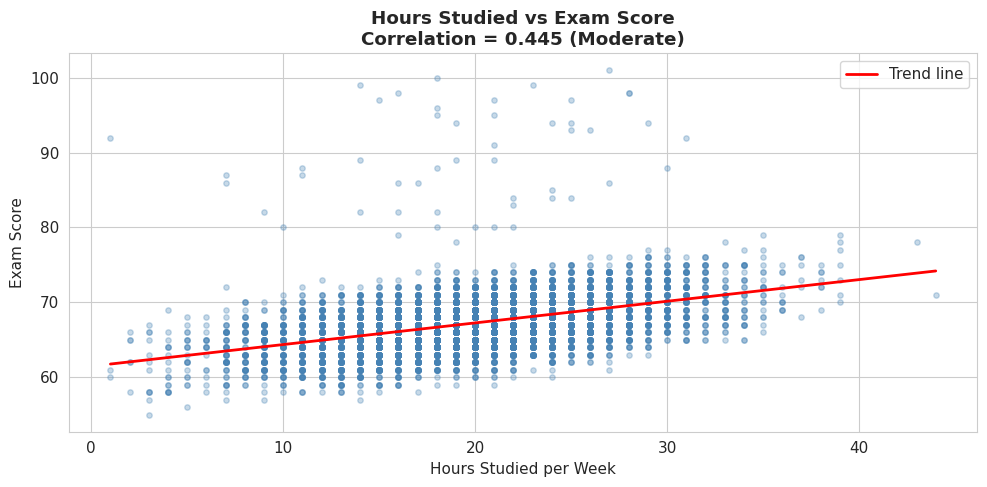


 KEY FINDING:
   Correlation between Hours_Studied and Exam_Score = 0.445


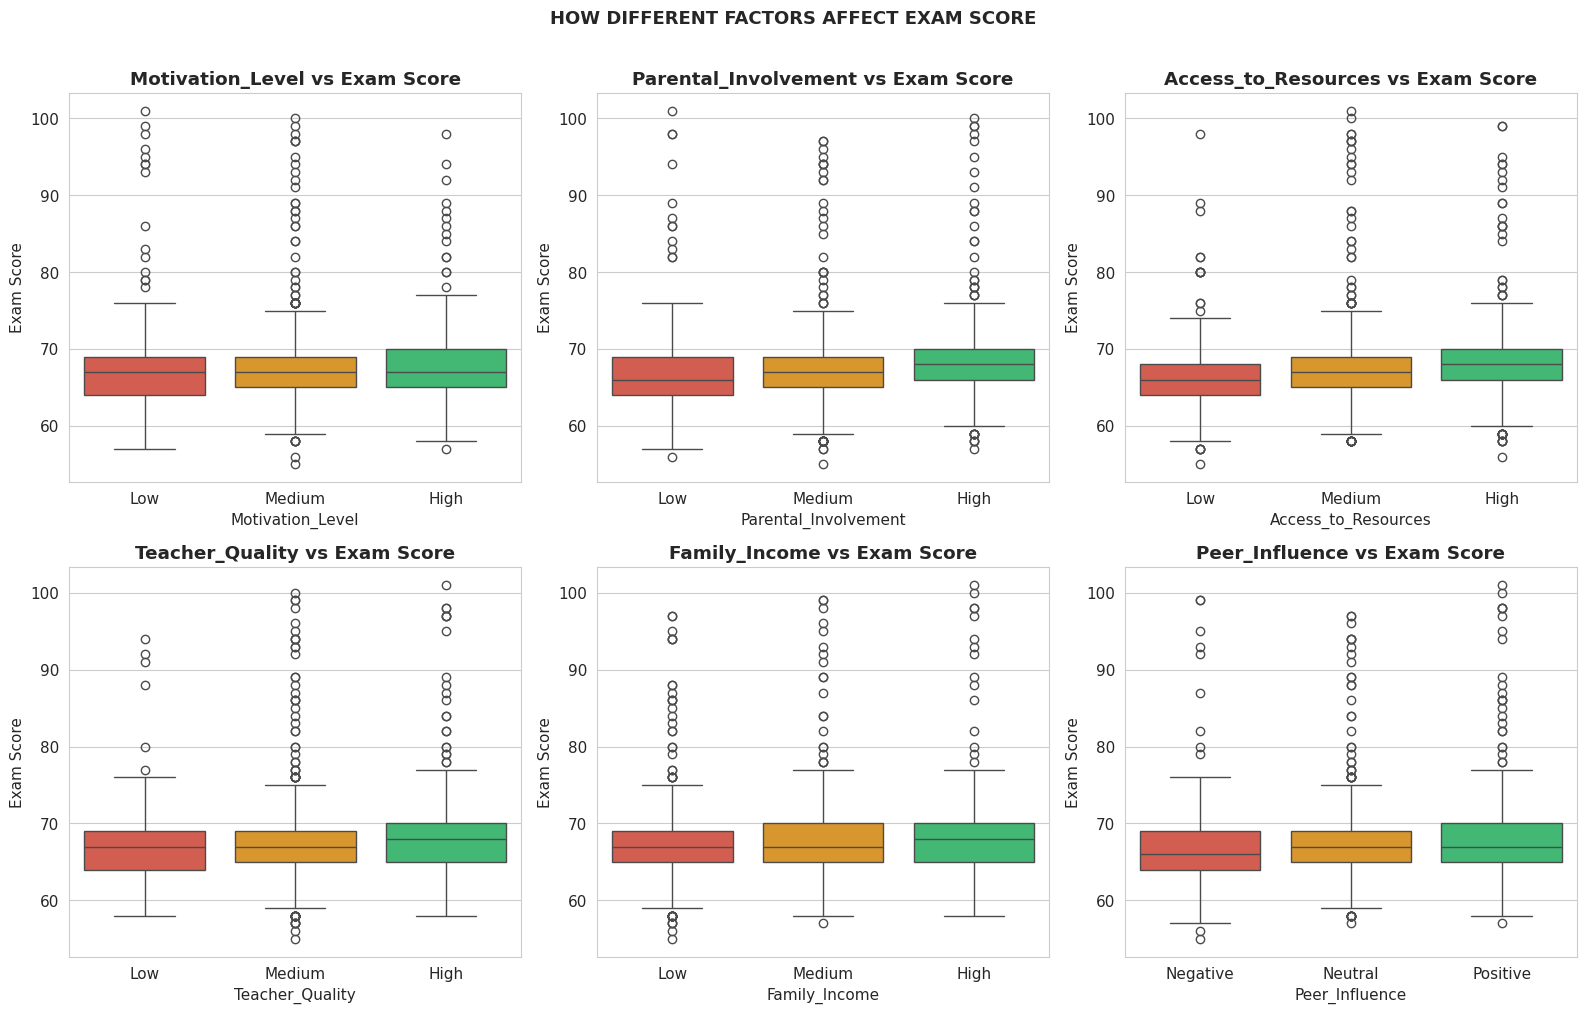

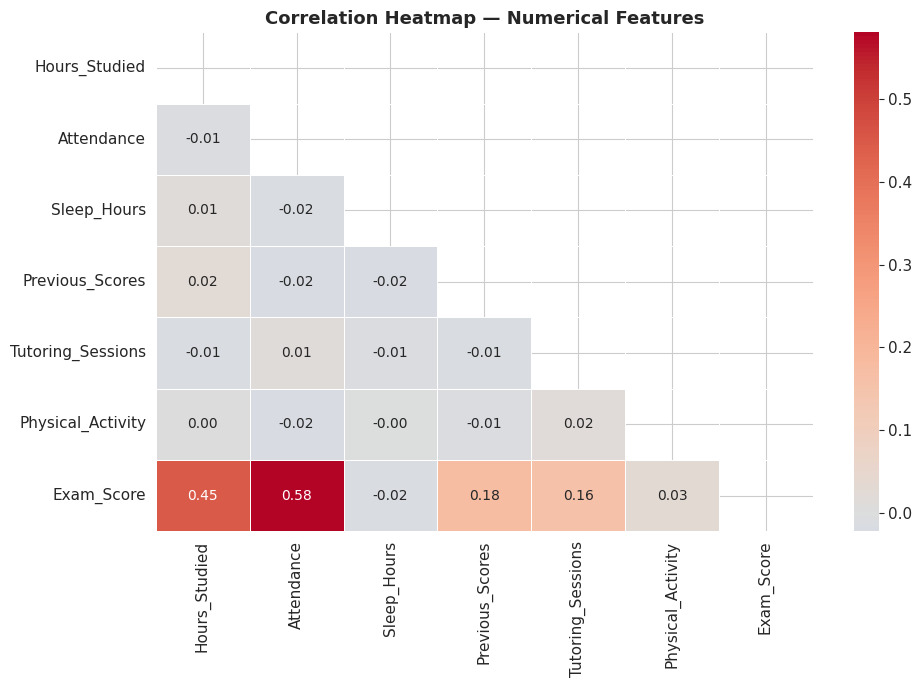


📌 KEY FINDING FROM HEATMAP:
   Hours_Studied             → correlation with Exam_Score = +0.445
   Attendance                → correlation with Exam_Score = +0.581
   Sleep_Hours               → correlation with Exam_Score = -0.017
   Previous_Scores           → correlation with Exam_Score = +0.175
   Tutoring_Sessions         → correlation with Exam_Score = +0.157
   Physical_Activity         → correlation with Exam_Score = +0.028


In [ ]:
# ============================================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# WHY: Visualising the data reveals patterns, problems,
#      and insights that numbers alone cannot show.
#      This is where we PROVE the imbalance exists
#      and show that high study ≠ always high marks.
# ============================================================

# ── Plot 1: Exam_Scaore Distribution ──────────────────────────
# WHY: This proves the imbalance problem visually.


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Exam_Score'], bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['Exam_Score'].mean(),
                color='red', linestyle='--',
                linewidth=2, label=f"Mean = {df['Exam_Score'].mean():.1f}")
axes[0].axvline(df['Exam_Score'].median(),
                color='orange', linestyle='--',
                linewidth=2, label=f"Median = {df['Exam_Score'].median():.1f}")
axes[0].set_title('Exam Score Distribution\n(Notice: heavily concentrated 65-74)',
                  fontweight='bold')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Score band breakdown (bar chart)
bands        = ['<60', '60-64', '65-69', '70-74', '75-79', '80+']
band_counts  = [
    (df['Exam_Score'] < 60).sum(),
    ((df['Exam_Score'] >= 60) & (df['Exam_Score'] < 65)).sum(),
    ((df['Exam_Score'] >= 65) & (df['Exam_Score'] < 70)).sum(),
    ((df['Exam_Score'] >= 70) & (df['Exam_Score'] < 75)).sum(),
    ((df['Exam_Score'] >= 75) & (df['Exam_Score'] < 80)).sum(),
    (df['Exam_Score'] >= 80).sum()
]
bar_colors = ['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#1abc9c']
bars = axes[1].bar(bands, band_counts, color=bar_colors,
                   edgecolor='black', linewidth=0.7)

# Add count labels on top of each bar
for bar, count in zip(bars, band_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 str(count), ha='center', fontweight='bold', fontsize=10)

axes[1].set_title('Students Per Score Band\n(97% score between 60-74)',
                  fontweight='bold')
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('Number of Students')

plt.suptitle('TARGET VARIABLE ANALYSIS — EXAM SCORE',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY FINDING:")
print(f"   97.1% of students score between 60 and 74")
print(f"   Only {(df['Exam_Score'] >= 80).sum()} students score 80+")
print(f"   This is CLASS IMBALANCE — we will fix it with SMOTE")


# ── Plot 2: Hours Studied vs Exam Score ──────────────────────
# WHY: This directly answers "does high study = high marks?"
#      The scatter plot will show the answer from real data.

plt.figure(figsize=(10, 5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'],
            alpha=0.3, color='steelblue', s=15)

# Add trend line
z   = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
p   = np.poly1d(z)
x_line = np.linspace(df['Hours_Studied'].min(),
                      df['Hours_Studied'].max(), 100)
plt.plot(x_line, p(x_line),
         color='red', linewidth=2, label='Trend line')

corr = df['Hours_Studied'].corr(df['Exam_Score'])
plt.title(f'Hours Studied vs Exam Score\n'
          f'Correlation = {corr:.3f} '
          f'({"Weak" if abs(corr)<0.3 else "Moderate"})',
          fontweight='bold')
plt.xlabel('Hours Studied per Week')
plt.ylabel('Exam Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_hours_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n KEY FINDING:")
print(f"   Correlation between Hours_Studied and Exam_Score = {corr:.3f}")
if abs(corr) < 0.3:
    print(f"   This is WEAK correlation.")
    print(f"   Proof: High study hours do NOT always mean high marks.")
    print(f"   Multiple features together explain performance better.")


# ── Plot 3: Categorical Features vs Exam Score ───────────────
# WHY: Shows how Motivation, Attendance, and other factors
#      actually relate to scores — using box plots.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Features to plot and their order for x-axis
cat_features = {
    'Motivation_Level'      : ['Low', 'Medium', 'High'],
    'Parental_Involvement'  : ['Low', 'Medium', 'High'],
    'Access_to_Resources'   : ['Low', 'Medium', 'High'],
    'Teacher_Quality'       : ['Low', 'Medium', 'High'],
    'Family_Income'         : ['Low', 'Medium', 'High'],
    'Peer_Influence'        : ['Negative', 'Neutral', 'Positive'],
}

palette = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, (feature, order) in zip(axes.flatten(), cat_features.items()):
    # Filter out NaN for plotting
    plot_data = df[[feature, 'Exam_Score']].dropna()
    sns.boxplot(data=plot_data, x=feature, y='Exam_Score',
                order=order, palette=palette, ax=ax)
    ax.set_title(f'{feature} vs Exam Score', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Exam Score')

plt.suptitle('HOW DIFFERENT FACTORS AFFECT EXAM SCORE',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot3_factors_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot 4: Correlation Heatmap ───────────────────────────────
# WHY: Shows which numerical features are most related
#      to Exam_Score. This guides feature selection later.

plt.figure(figsize=(10, 7))
num_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 10})

plt.title('Correlation Heatmap — Numerical Features',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 KEY FINDING FROM HEATMAP:")
for col in num_cols:
    if col != 'Exam_Score':
        c = df[col].corr(df['Exam_Score'])
        print(f"   {col:25s} → correlation with Exam_Score = {c:+.3f}")

BLOCK 4 — Preprocessing

In [ ]:
# ============================================================
# BLOCK 4: PREPROCESSING
# ============================================================
# WHY: Raw data cannot be fed to ML models directly.
#      We need to clean, encode, and scale it.
#      Every decision here must be justified — not random.
# ============================================================

# Work on a copy — never modify original data
df_clean = df.copy()

print("=" * 55)
print("STEP 4A: HANDLE OUTLIERS")
print("=" * 55)

# Exam_Score has a max of 101 — impossible if exam is out of 100
print(f"Before: Max Exam_Score = {df_clean['Exam_Score'].max()}")
print(f"        Rows with score > 100: "
      f"{(df_clean['Exam_Score'] > 100).sum()}")

# Cap at 100 (more conservative than removing)
df_clean['Exam_Score'] = df_clean['Exam_Score'].clip(upper=100)
print(f"After : Max Exam_Score = {df_clean['Exam_Score'].max()}")
print(f" Outlier capped. Justification: exam cannot exceed 100.")


print("\n" + "=" * 55)
print("STEP 4B: HANDLE MISSING VALUES")
print("=" * 55)
# WHY mode: these are categorical columns.
#           Mode = most common value = safest fill.
# WHY not drop rows: only 1-1.5% missing — dropping wastes data.

cols_with_missing = ['Teacher_Quality',
                     'Parental_Education_Level',
                     'Distance_from_Home']

for col in cols_with_missing:
    mode_val    = df_clean[col].mode()[0]
    missing_cnt = df_clean[col].isnull().sum()
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  {col}:")
    print(f"    Missing count : {missing_cnt}")
    print(f"    Filled with   : '{mode_val}' (mode)")
    print(f"    Missing after : {df_clean[col].isnull().sum()}")

print(f"\n All missing values handled.")
print(f"   Total missing now: {df_clean.isnull().sum().sum()}")


print("\n" + "=" * 55)
print("STEP 4C: ENCODING")
print("=" * 55)

# ── Ordinal Encoding (ordered categories) ────────────────────
# WHY Ordinal: Low < Medium < High has real mathematical meaning.
#              The model should know High(2) > Medium(1) > Low(0).

print("\n  [Ordinal Encoding] — for ordered categories:")

ordinal_mappings = {
    'Parental_Involvement'   : ['Low', 'Medium', 'High'],
    'Access_to_Resources'    : ['Low', 'Medium', 'High'],
    'Motivation_Level'       : ['Low', 'Medium', 'High'],
    'Family_Income'          : ['Low', 'Medium', 'High'],
    'Teacher_Quality'        : ['Low', 'Medium', 'High'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home'     : ['Near', 'Moderate', 'Far'],
}

for col, order in ordinal_mappings.items():
    mapping = {val: idx for idx, val in enumerate(order)}
    df_clean[col] = df_clean[col].map(mapping)
    print(f"    {col:30s}: {mapping}")

# ── Label Encoding (binary, no order) ────────────────────────
# WHY Label: only 2 values — 0 and 1 is sufficient.
#            No false ordering introduced.

print("\n  [Label Encoding] — for binary categories:")

binary_mappings = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access'           : {'No': 0, 'Yes': 1},
    'Learning_Disabilities'     : {'No': 0, 'Yes': 1},
    'Gender'                    : {'Female': 0, 'Male': 1},
    'School_Type'               : {'Public': 0, 'Private': 1},
}

for col, mapping in binary_mappings.items():
    df_clean[col] = df_clean[col].map(mapping)
    print(f"    {col:30s}: {mapping}")

# ── One-Hot Encoding (no order, >2 categories) ───────────────
# WHY One-Hot: Peer_Influence has no mathematical order.
#              Positive is NOT greater than Negative.
#              One-Hot treats each as independent.

print("\n  [One-Hot Encoding] — for Peer_Influence:")

df_clean = pd.get_dummies(df_clean,
                           columns=['Peer_Influence'],
                           prefix='Peer',
                           drop_first=False)
# Convert boolean columns to int (0/1)
peer_cols = [c for c in df_clean.columns if c.startswith('Peer_')]
df_clean[peer_cols] = df_clean[peer_cols].astype(int)
print(f"    Created columns: {peer_cols}")

print(f"\n  Dataset shape after encoding: {df_clean.shape}")


print("\n" + "=" * 55)
print("STEP 4D: CREATE TARGET VARIABLES")
print("=" * 55)

# ── Regression target: keep Exam_Score as-is ─────────────────
# Already cleaned above (capped at 100)

# ── Classification target: binary split at MEDIAN ────────────
# WHY median (67): gives the most balanced split possible
#     given the severe score concentration in this dataset.
#     Splitting at 70 or 75 would create extreme imbalance.

median_score = df_clean['Exam_Score'].median()
df_clean['Pass_Fail'] = (df_clean['Exam_Score'] >= median_score).astype(int)

print(f"  Median score used as split point: {median_score}")
print(f"\n  Class distribution:")
vc = df_clean['Pass_Fail'].value_counts()
for cls, count in vc.items():
    label = 'Pass (1)' if cls == 1 else 'Fail (0)'
    pct   = count / len(df_clean) * 100
    print(f"    {label}: {count} students ({pct:.1f}%)")

print(f"\n Binary target created.")
print(f"   Pass = Exam_Score >= {median_score}")
print(f"   Fail = Exam_Score <  {median_score}")


print("\n" + "=" * 55)
print("STEP 4E: FEATURE SCALING")
print("=" * 55)
# WHY MinMaxScaler: brings all values to [0, 1] range.
#     Distance-based models (KNN, SVM) need this —
#     otherwise Hours_Studied (1-44) dominates over
#     Sleep_Hours (6-10) unfairly.
# WHY NOT scale target: we scale features only,
#     never the thing we're trying to predict.

cols_to_scale = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity'
]

scaler = MinMaxScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print(f"  Scaled columns: {cols_to_scale}")
print(f"  All values now in [0, 1] range.")
print(f"\n  Sample after scaling:")
print(df_clean[cols_to_scale].head(3).round(3))

print(f"\n PREPROCESSING COMPLETE")
print(f"   Final dataset shape: {df_clean.shape}")
print(f"   All columns now numerical — ready for ML.")

STEP 4A: HANDLE OUTLIERS
Before: Max Exam_Score = 101
        Rows with score > 100: 1
After : Max Exam_Score = 100
 Outlier capped. Justification: exam cannot exceed 100.

STEP 4B: HANDLE MISSING VALUES
  Teacher_Quality:
    Missing count : 78
    Filled with   : 'Medium' (mode)
    Missing after : 0
  Parental_Education_Level:
    Missing count : 90
    Filled with   : 'High School' (mode)
    Missing after : 0
  Distance_from_Home:
    Missing count : 67
    Filled with   : 'Near' (mode)
    Missing after : 0

 All missing values handled.
   Total missing now: 0

STEP 4C: ENCODING

  [Ordinal Encoding] — for ordered categories:
    Parental_Involvement          : {'Low': 0, 'Medium': 1, 'High': 2}
    Access_to_Resources           : {'Low': 0, 'Medium': 1, 'High': 2}
    Motivation_Level              : {'Low': 0, 'Medium': 1, 'High': 2}
    Family_Income                 : {'Low': 0, 'Medium': 1, 'High': 2}
    Teacher_Quality               : {'Low': 0, 'Medium': 1, 'High': 2}
    P

BLOCK 5 — Clustering

STEP 5A: FIND OPTIMAL k (Elbow Method)
  k=2: Inertia = 2724.92
  k=3: Inertia = 1778.05
  k=4: Inertia = 1571.18
  k=5: Inertia = 1449.34
  k=6: Inertia = 1322.89
  k=7: Inertia = 1237.98
  k=8: Inertia = 1159.07
  k=9: Inertia = 1083.76


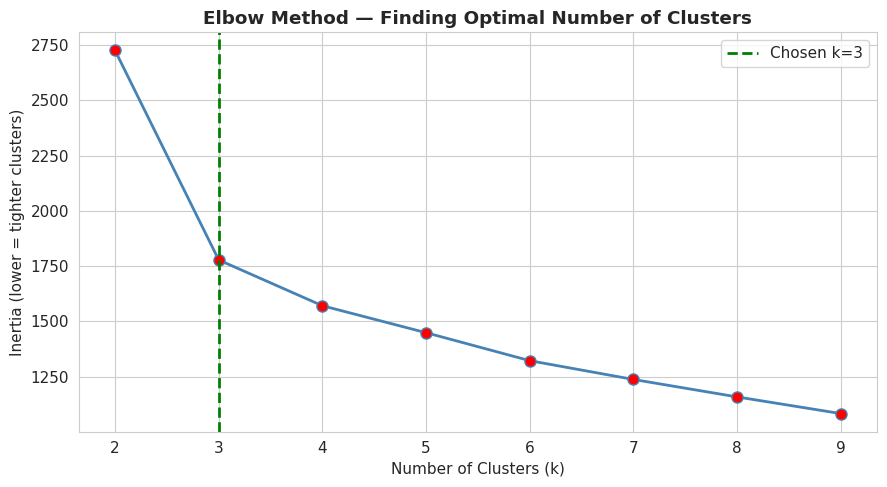


 JUSTIFICATION for k=3:
   k=3 gives 3 natural groups: Low / Medium / High risk
   These directly map to student support categories
   Interpretable for educators and stakeholders

STEP 5B: APPLY K-MEANS WITH k=3
K-Means applied. Cluster counts:
Cluster
0    1319
1    3351
2    1937
Name: count, dtype: int64

STEP 5C: ANALYSE AND LABEL EACH CLUSTER

Cluster Summary:
         Hours_mean  Attendance_mean  Motivation_mean  PrevScore_mean  Tutoring_mean  Exam_mean  Pass_rate  Count
Cluster                                                                                                          
0             0.436            0.493              2.0           0.512          0.189     67.704      0.608   1319
1             0.444            0.503              1.0           0.496          0.185     67.331      0.576   3351
2             0.441            0.498              0.0           0.504          0.188     66.752      0.513   1937

Risk Labels Assigned:
  Cluster 0 → Low Risk     | Pass Rat

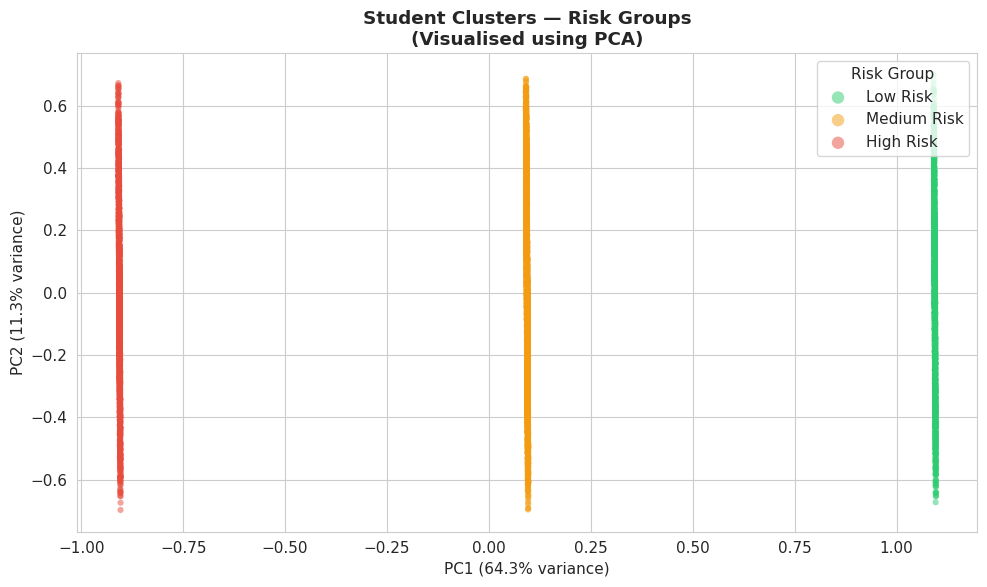

risk_map = {0: 0, 1: 1, 2: 2}

 CLUSTERING COMPLETE
   Cluster label added as feature 'Risk_Group_Encoded'
   This feature will be used in supervised models.


In [ ]:
# ============================================================
# BLOCK 5: CLUSTERING (K-Means)
# ============================================================
# WHY BEFORE feature selection: Clustering reveals which
#     features naturally group students. Those cluster-defining
#     features are obviously important → smarter selection later.
# WHY K-Means: Simple, interpretable, works well for grouping
#     students into Low/Medium/High risk profiles.
# ============================================================

print("=" * 55)
print("STEP 5A: FIND OPTIMAL k (Elbow Method)")
print("=" * 55)

# Features used for clustering — behavioural + academic
# WHY these: they best capture a student's overall profile
cluster_features = [
    'Hours_Studied',
    'Attendance',
    'Motivation_Level',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Sleep_Hours'
]

X_cluster = df_clean[cluster_features]

# Elbow method: run K-Means for k=2 to 9
# Plot inertia (total distance of points from their cluster centre)
# The "elbow" point = best k

inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42,
                n_init=10, max_iter=300)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
    print(f"  k={k}: Inertia = {km.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertia,
         marker='o', color='steelblue',
         linewidth=2, markersize=8, markerfacecolor='red')
plt.axvline(x=3, color='green', linestyle='--',
            linewidth=2, label='Chosen k=3')
plt.title('Elbow Method — Finding Optimal Number of Clusters',
          fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.savefig('plot5_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n JUSTIFICATION for k=3:")
print(f"   k=3 gives 3 natural groups: Low / Medium / High risk")
print(f"   These directly map to student support categories")
print(f"   Interpretable for educators and stakeholders")


print("\n" + "=" * 55)
print("STEP 5B: APPLY K-MEANS WITH k=3")
print("=" * 55)

kmeans = KMeans(n_clusters=3, random_state=42,
                n_init=10, max_iter=300)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster)

print("K-Means applied. Cluster counts:")
print(df_clean['Cluster'].value_counts().sort_index())


print("\n" + "=" * 55)
print("STEP 5C: ANALYSE AND LABEL EACH CLUSTER")
print("=" * 55)

# Understand what each cluster represents
cluster_summary = df_clean.groupby('Cluster').agg(
    Hours_mean     = ('Hours_Studied',    'mean'),
    Attendance_mean= ('Attendance',       'mean'),
    Motivation_mean= ('Motivation_Level', 'mean'),
    PrevScore_mean = ('Previous_Scores',  'mean'),
    Tutoring_mean  = ('Tutoring_Sessions','mean'),
    Exam_mean      = ('Exam_Score',       'mean'),
    Pass_rate      = ('Pass_Fail',        'mean'),
    Count          = ('Exam_Score',       'count')
).round(3)

print("\nCluster Summary:")
print(cluster_summary.to_string())

# Auto-label by pass rate (highest pass rate = lowest risk)
pass_rates    = cluster_summary['Pass_rate'].sort_values(ascending=False)
risk_map      = {
    pass_rates.index[0]: 'Low Risk',
    pass_rates.index[1]: 'Medium Risk',
    pass_rates.index[2]: 'High Risk'
}
df_clean['Risk_Group'] = df_clean['Cluster'].map(risk_map)

print("\nRisk Labels Assigned:")
for cluster_id, label in risk_map.items():
    pr = cluster_summary.loc[cluster_id, 'Pass_rate']
    ct = cluster_summary.loc[cluster_id, 'Count']
    print(f"  Cluster {cluster_id} → {label:12s} "
          f"| Pass Rate: {pr*100:.1f}% | Students: {ct}")


print("\n" + "=" * 55)
print("STEP 5D: VISUALISE CLUSTERS")
print("=" * 55)

# PCA to reduce to 2D for visualisation
# WHY PCA: we have 6 cluster features — can't plot in 6D.
#          PCA reduces to 2D while keeping max information.

pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_cluster)

var_explained = pca.explained_variance_ratio_ * 100
print(f"PCA: PC1 explains {var_explained[0]:.1f}% variance")
print(f"     PC2 explains {var_explained[1]:.1f}% variance")
print(f"     Together   : {sum(var_explained):.1f}% of information kept")

colors = {'Low Risk': '#2ecc71',
          'Medium Risk': '#f39c12',
          'High Risk': '#e74c3c'}

plt.figure(figsize=(10, 6))
for group, color in colors.items():
    mask = df_clean['Risk_Group'] == group
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=group,
                alpha=0.5, s=20,
                edgecolors='none')

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
plt.title('Student Clusters — Risk Groups\n(Visualised using PCA)',
          fontweight='bold')
plt.legend(title='Risk Group', markerscale=2)
plt.tight_layout()
plt.savefig('plot5_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Encode Risk_Group as number for use as ML feature
risk_encode = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
df_clean['Risk_Group_Encoded'] = df_clean['Risk_Group'].map(risk_encode)

# Fix risk_map to use numbers instead of text — needed for predictor
risk_map = {
    int(pass_rates.index[0]): 0,
    int(pass_rates.index[1]): 1,
    int(pass_rates.index[2]): 2
}

print(f"risk_map = {risk_map}")
print(f"\n CLUSTERING COMPLETE")
print(f"   Cluster label added as feature 'Risk_Group_Encoded'")
print(f"   This feature will be used in supervised models.")

BLOCK 6 — Feature Selection

In [ ]:
# ============================================================
# BLOCK 6: FEATURE SELECTION
# ============================================================
# WHY AFTER clustering: the Risk_Group_Encoded feature
#     (from clustering) is now included and evaluated.
#     Features that defined clusters may rank highly here.
# WHY 3 methods: a feature removed by ALL 3 methods
#     is provably useless — not just assumed useless.
# ============================================================

print("=" * 55)
print("PREPARING FEATURE SETS")
print("=" * 55)

# Drop columns we don't use as features
drop_always = ['Exam_Score',          # target — never a feature
               'Pass_Fail',           # target — never a feature
               'Cluster',             # raw cluster ID (replaced by encoded)
               'Risk_Group',          # text label — replaced by encoded
               'Peer_Influence_Positive',
               'Peer_Influence_Neutral',
               'Peer_Influence_Negative']

# Wait — check which peer columns actually exist
peer_cols_exist = [c for c in df_clean.columns
                   if c.startswith('Peer_')]
print(f"Peer columns in dataset: {peer_cols_exist}")

drop_always = ['Exam_Score', 'Pass_Fail',
               'Cluster', 'Risk_Group'] + peer_cols_exist

# Add peer columns back properly (they ARE features)
# Remove from drop list
drop_always = ['Exam_Score', 'Pass_Fail', 'Cluster', 'Risk_Group']

# Full feature matrix
X_full = df_clean.drop(columns=drop_always)
y_reg  = df_clean['Exam_Score']   # regression target
y_cls  = df_clean['Pass_Fail']    # classification target

print(f"\nFull feature set: {X_full.shape[1]} features")
print(f"Features: {list(X_full.columns)}")


print("\n" + "=" * 55)
print("METHOD 1: CORRELATION ANALYSIS")
print("=" * 55)
# WHY: Measures linear relationship between each feature
#      and the target. High |correlation| = more useful.

corr_with_target = X_full.corrwith(y_reg).abs().sort_values(ascending=False)

print("\nFeature correlations with Exam_Score:")
for feat, corr_val in corr_with_target.items():
    bar     = '█' * int(corr_val * 30)
    flag    = ' ← WEAK' if corr_val < 0.05 else ''
    print(f"  {feat:35s}: {corr_val:.4f}  {bar}{flag}")

weak_corr = corr_with_target[corr_with_target < 0.05].index.tolist()
print(f"\nWeak by correlation (< 0.05): {weak_corr}")


print("\n" + "=" * 55)
print("METHOD 2: RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 55)
# WHY: Captures non-linear relationships that
#      correlation (linear only) misses.

rf_quick = RandomForestRegressor(n_estimators=100, random_state=42)
rf_quick.fit(X_full, y_reg)

importance_df = pd.DataFrame({
    'Feature'   : X_full.columns,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nRandom Forest Feature Importance:")
for _, row in importance_df.iterrows():
    bar  = '█' * int(row['Importance'] * 200)
    flag = ' ← LOW' if row['Importance'] < 0.01 else ''
    print(f"  {row['Feature']:35s}: {row['Importance']:.4f}  {bar}{flag}")

low_importance = importance_df[
    importance_df['Importance'] < 0.01
]['Feature'].tolist()
print(f"\nLow importance features (< 0.01): {low_importance}")


print("\n" + "=" * 55)
print("METHOD 3: RFE (Recursive Feature Elimination)")
print("=" * 55)
# WHY: Considers how features interact with each other —
#      not just each feature independently.
#      Uses Logistic Regression as base estimator.

lr_rfe = LogisticRegression(max_iter=1000, random_state=42)
rfe    = RFE(estimator=lr_rfe, n_features_to_select=12)
rfe.fit(X_full, y_cls)

rfe_df = pd.DataFrame({
    'Feature' : X_full.columns,
    'Selected': rfe.support_,
    'Ranking' : rfe.ranking_
}).sort_values('Ranking')

print("\nRFE Results:")
for _, row in rfe_df.iterrows():
    status = ' SELECTED' if row['Selected'] else ' Eliminated'
    print(f"  Rank {row['Ranking']:2.0f} | {row['Feature']:35s} | {status}")

rfe_eliminated = rfe_df[~rfe_df['Selected']]['Feature'].tolist()


print("\n" + "=" * 55)
print("FINAL FEATURE DECISION")
print("=" * 55)

# Remove only features flagged by ALL 3 methods
flagged_all = (set(weak_corr) &
               set(low_importance) &
               set(rfe_eliminated))

print(f"Features weak in ALL 3 methods: {flagged_all}")

if flagged_all:
    print("These will be REMOVED — justified by all 3 methods.")
else:
    print("No feature is weak in ALL 3 methods.")
    print("We keep top features by RF importance instead.")
    # Keep top 15 by importance
    flagged_all = set(
        importance_df.tail(
            max(0, len(importance_df) - 15)
        )['Feature'].tolist()
    )
    print(f"Removing bottom features: {flagged_all}")

# Build final feature set
features_to_keep = [f for f in X_full.columns
                    if f not in flagged_all]
X_final = X_full[features_to_keep]

print(f"\nFeatures kept : {len(features_to_keep)}")
print(f"Features list : {features_to_keep}")

# ── Prove removal is justified ────────────────────────────────
# F1 score should NOT drop after removal
from sklearn.model_selection import cross_val_score
lr_check   = LogisticRegression(max_iter=1000, random_state=42)
f1_before  = cross_val_score(lr_check, X_full,  y_cls,
                              cv=5, scoring='f1').mean()
f1_after   = cross_val_score(lr_check, X_final, y_cls,
                              cv=5, scoring='f1').mean()

print(f"\nF1 Score with ALL {X_full.shape[1]} features  : {f1_before:.4f}")
print(f"F1 Score with {len(features_to_keep)} selected features: {f1_after:.4f}")

if f1_after >= f1_before - 0.01:
    print("JUSTIFIED: Performance did not drop.")
    print("   Feature removal is data-proven, not assumed.")
else:
    print("  Performance dropped. Keeping all features.")
    X_final = X_full.copy()

# ── Build TWO feature sets ────────────────────────────────────
print("\n" + "=" * 55)
print("BUILDING TWO FEATURE SETS")
print("=" * 55)
print("  Model 1: WITH Previous_Scores  → high accuracy")
print("  Model 2: WITHOUT Previous_Scores → actionable insights")

X_with_prev    = X_final.copy()
X_without_prev = X_final.drop(
    columns=['Previous_Scores'], errors='ignore'
)

print(f"\n  X_with_prev    shape: {X_with_prev.shape}")
print(f"  X_without_prev shape: {X_without_prev.shape}")
print("Both feature sets ready.")

PREPARING FEATURE SETS
Peer columns in dataset: ['Peer_Negative', 'Peer_Neutral', 'Peer_Positive']

Full feature set: 22 features
Features: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Peer_Negative', 'Peer_Neutral', 'Peer_Positive', 'Risk_Group_Encoded']

METHOD 1: CORRELATION ANALYSIS

Feature correlations with Exam_Score:
  Attendance                         : 0.5812  █████████████████
  Hours_Studied                      : 0.4456  █████████████
  Previous_Scores                    : 0.1751  █████
  Access_to_Resources                : 0.1698  █████
  Parental_Involvement               : 0.1572  ████
  Tutoring_Sessions                  : 0.1565  ████
  Parental_Education_

BLOCK 7 — Train Test Split + SMOTE

In [ ]:
# ================================================================
# STEP 7: TRAIN TEST SPLIT + SMOTE
# ================================================================
# We split FIRST, then apply SMOTE only on training data.
# Test data must stay real — never balance test data.
# ================================================================

print("STEP 7: TRAIN TEST SPLIT")
print("=" * 50)

# --- Split for CLASSIFICATION (with Previous_Scores) ---
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_with_prev, y_cls,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y_cls   # keeps same Pass/Fail ratio in both sets
)

# --- Split for CLASSIFICATION (without Previous_Scores) ---
X_train_cls2, X_test_cls2, y_train_cls2, y_test_cls2 = train_test_split(
    X_without_prev, y_cls,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y_cls
)

# --- Split for REGRESSION (with Previous_Scores) ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_with_prev, y_reg,
    test_size   = 0.2,
    random_state= 42
)

# --- Split for REGRESSION (without Previous_Scores) ---
X_train_reg2, X_test_reg2, y_train_reg2, y_test_reg2 = train_test_split(
    X_without_prev, y_reg,
    test_size   = 0.2,
    random_state= 42
)

print(f"Training students : {len(X_train_cls)}")
print(f"Testing  students : {len(X_test_cls)}")

print(f"\nClass balance in training set BEFORE SMOTE:")
print(f"  Pass (1) : {y_train_cls.sum()}")
print(f"  Fail (0) : {(y_train_cls==0).sum()}")


print("\nSTEP 7B: APPLYING SMOTE")
print("=" * 50)
# SMOTE creates fake but realistic students in the
# minority class so the model learns both classes equally.
# ONLY applied on training data — never on test data.

smote = SMOTE(random_state=42)

# For model 1 (with Previous_Scores)
X_train_cls_sm, y_train_cls_sm = smote.fit_resample(
    X_train_cls, y_train_cls
)

# For model 2 (without Previous_Scores)
X_train_cls2_sm, y_train_cls2_sm = smote.fit_resample(
    X_train_cls2, y_train_cls2
)

print(f"Class balance AFTER SMOTE:")
print(f"  Pass (1) : {y_train_cls_sm.sum()}")
print(f"  Fail (0) : {(y_train_cls_sm==0).sum()}")
print(f"\n Both classes now equal — model will learn fairly")
print(f"Test data untouched — still real students only")

STEP 7: TRAIN TEST SPLIT
Training students : 5285
Testing  students : 1322

Class balance in training set BEFORE SMOTE:
  Pass (1) : 2980
  Fail (0) : 2305

STEP 7B: APPLYING SMOTE
Class balance AFTER SMOTE:
  Pass (1) : 2980
  Fail (0) : 2980

 Both classes now equal — model will learn fairly
Test data untouched — still real students only


BLOCK 8 — Classification Models

STEP 8: CLASSIFICATION MODELS

--- MODEL SET 1: With Previous_Scores ---
   Logistic Regression done
   Decision Tree done
   Random Forest done
   SVM done
   KNN done

Results (With Previous_Scores):
              Model  CV F1 (mean)  Test F1  Precision  Recall  ROC-AUC     Gap Overfit?
Logistic Regression        0.9712   0.9799     0.9799  0.9799   0.9937 -0.0011       No
                SVM        0.9378   0.9559     0.9670  0.9450   0.9870  0.0146       No
      Random Forest        0.9193   0.9157     0.9132  0.9181   0.9654  0.0953      Yes
      Decision Tree        0.8452   0.8476     0.8593  0.8362   0.9142  0.0345       No
                KNN        0.7239   0.7312     0.7377  0.7248   0.7523  0.1334      Yes

--- MODEL SET 2: Without Previous_Scores ---
  Logistic Regression done
  Decision Tree done
  Random Forest done
  SVM done
  KNN done

Results (Without Previous_Scores):
              Model  CV F1 (mean)  Test F1  Precision  Recall  ROC-AUC    Gap Overfit?
Logistic R

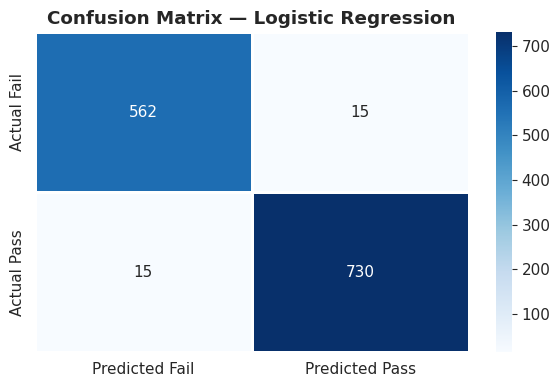


True Negatives  (Predicted Fail, Actually Fail) : 562
False Positives (Predicted Pass, Actually Fail) : 15
False Negatives (Predicted Fail, Actually Pass) : 15
True Positives  (Predicted Pass, Actually Pass) : 730

Full Classification Report:
              precision    recall  f1-score   support

        Fail       0.97      0.97      0.97       577
        Pass       0.98      0.98      0.98       745

    accuracy                           0.98      1322
   macro avg       0.98      0.98      0.98      1322
weighted avg       0.98      0.98      0.98      1322



In [ ]:
# ================================================================
# STEP 8: CLASSIFICATION — TRAIN AND COMPARE 5 MODELS
# ================================================================
# We run the same 5 models on both feature sets and compare.
# Cross-validation gives reliable scores (not just one split).
# Overfitting check shows if model memorised or truly learned.
# ================================================================

print("STEP 8: CLASSIFICATION MODELS")
print("=" * 50)

# Define the 5 models
cls_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

# ── Helper function to evaluate one model ────────────────────
def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, label):
    # Train
    model.fit(X_tr, y_tr)

    # Cross-validation (5-fold) on training data
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='f1')

    # Predictions on test data
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    # Overfitting check
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc  = accuracy_score(y_te, y_pred)
    gap       = train_acc - test_acc

    return {
        'Model'        : label,
        'CV F1 (mean)' : round(cv_scores.mean(), 4),
        'CV F1 (std)'  : round(cv_scores.std(),  4),
        'Test Accuracy': round(test_acc,                               4),
        'Test F1'      : round(f1_score(y_te, y_pred),                4),
        'Precision'    : round(precision_score(y_te, y_pred),         4),
        'Recall'       : round(recall_score(y_te, y_pred),            4),
        'ROC-AUC'      : round(roc_auc_score(y_te, y_prob),           4),
        'Train Acc'    : round(train_acc,                              4),
        'Gap'          : round(gap,                                    4),
        'Overfit?'     : ' Yes' if gap > 0.05 else ' No'
    }


# ── MODEL SET 1: With Previous_Scores ────────────────────────
print("\n--- MODEL SET 1: With Previous_Scores ---")
results1 = []
trained_cls1 = {}

for name, model in cls_models.items():
    r = evaluate_classifier(
        model,
        X_train_cls_sm, y_train_cls_sm,
        X_test_cls,     y_test_cls,
        name
    )
    results1.append(r)
    trained_cls1[name] = model
    print(f"   {name} done")

df_results1 = pd.DataFrame(results1).sort_values('Test F1', ascending=False)
print("\nResults (With Previous_Scores):")
print(df_results1[['Model','CV F1 (mean)','Test F1',
                    'Precision','Recall','ROC-AUC',
                    'Gap','Overfit?']].to_string(index=False))


# ── MODEL SET 2: Without Previous_Scores ─────────────────────
print("\n--- MODEL SET 2: Without Previous_Scores ---")
results2 = []
trained_cls2 = {}

for name, model in cls_models.items():
    # Re-initialise model (fresh, not already fitted)
    fresh_model = cls_models[name].__class__(
        **{k: v for k, v in cls_models[name].get_params().items()}
    )
    r = evaluate_classifier(
        fresh_model,
        X_train_cls2_sm, y_train_cls2_sm,
        X_test_cls2,     y_test_cls2,
        name
    )
    results2.append(r)
    trained_cls2[name] = fresh_model
    print(f"  {name} done")

df_results2 = pd.DataFrame(results2).sort_values('Test F1', ascending=False)
print("\nResults (Without Previous_Scores):")
print(df_results2[['Model','CV F1 (mean)','Test F1',
                    'Precision','Recall','ROC-AUC',
                    'Gap','Overfit?']].to_string(index=False))


# ── Pick best model from each set ────────────────────────────
best_name1  = df_results1.iloc[0]['Model']
best_name2  = df_results2.iloc[0]['Model']
best_model1 = trained_cls1[best_name1]
best_model2 = trained_cls2[best_name2]

print(f"\n Best Model (With Prev Scores)    : {best_name1}")
print(f"     Best Model (Without Prev Scores) : {best_name2}")


# ── Confusion Matrix for best model ──────────────────────────
print("\nCONFUSION MATRIX — Best Model (With Previous_Scores)")
print("=" * 50)

y_pred_best = best_model1.predict(X_test_cls)
cm = confusion_matrix(y_test_cls, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail',    'Actual Pass'],
            linewidths=1)
plt.title(f'Confusion Matrix — {best_name1}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (Predicted Fail, Actually Fail) : {cm[0][0]}")
print(f"False Positives (Predicted Pass, Actually Fail) : {cm[0][1]}")
print(f"False Negatives (Predicted Fail, Actually Pass) : {cm[1][0]}")
print(f"True Positives  (Predicted Pass, Actually Pass) : {cm[1][1]}")

print("\nFull Classification Report:")
print(classification_report(y_test_cls, y_pred_best,
                             target_names=['Fail','Pass']))

BLOCK 9 — Regression Models

In [ ]:
# ================================================================
# STEP 9: REGRESSION — PREDICT ACTUAL EXAM SCORE
# ================================================================
# Instead of Pass/Fail, here we predict the actual number.
# No SMOTE needed — regression predicts a number not a class.
# We report MAE (average error in score points).
# ================================================================

print("STEP 9: REGRESSION MODELS")
print("=" * 50)

reg_models = {
    'Linear Regression'  : LinearRegression(),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR'                : SVR(),
    'KNN'                : KNeighborsRegressor(n_neighbors=5)
}

def evaluate_regressor(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)

    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5,
                                scoring='neg_mean_absolute_error')
    cv_mae = -cv_scores.mean()

    # Test predictions
    y_pred     = model.predict(X_te)
    test_mae   = mean_absolute_error(y_te, y_pred)
    test_r2    = r2_score(y_te, y_pred)

    # Overfitting check
    train_mae  = mean_absolute_error(y_tr, model.predict(X_tr))
    gap        = train_mae - test_mae  # negative gap = overfitting

    return {
        'Model'        : label,
        'CV MAE'       : round(cv_mae,   4),
        'Test MAE'     : round(test_mae, 4),
        'Test R²'      : round(test_r2,  4),
        'Train MAE'    : round(train_mae,4),
        'Overfit?'     : '⚠️ Yes' if abs(gap) > 1.0 else ' No'
    }


# ── Model Set 1: With Previous_Scores ────────────────────────
print("\n--- REGRESSION SET 1: With Previous_Scores ---")
reg_results1 = []
trained_reg1 = {}

for name, model in reg_models.items():
    r = evaluate_regressor(
        model,
        X_train_reg, y_train_reg,
        X_test_reg,  y_test_reg,
        name
    )
    reg_results1.append(r)
    trained_reg1[name] = model
    print(f"   {name} done")

df_reg1 = pd.DataFrame(reg_results1).sort_values('Test MAE')
print("\nResults (With Previous_Scores) — lower MAE is better:")
print(df_reg1.to_string(index=False))


# ── Model Set 2: Without Previous_Scores ─────────────────────
print("\n--- REGRESSION SET 2: Without Previous_Scores ---")
reg_results2 = []
trained_reg2 = {}

for name, model in reg_models.items():
    fresh = reg_models[name].__class__(
        **{k: v for k, v in reg_models[name].get_params().items()}
    )
    r = evaluate_regressor(
        fresh,
        X_train_reg2, y_train_reg2,
        X_test_reg2,  y_test_reg2,
        name
    )
    reg_results2.append(r)
    trained_reg2[name] = fresh
    print(f"   {name} done")

df_reg2 = pd.DataFrame(reg_results2).sort_values('Test MAE')
print("\nResults (Without Previous_Scores):")
print(df_reg2.to_string(index=False))

# Pick best regression model
best_reg_name  = df_reg1.iloc[0]['Model']
best_reg_model = trained_reg1[best_reg_name]
print(f"\n Best Regression Model: {best_reg_name}")

# Honest report — MAE per score range
print("\n HONEST REPORTING — Error by Score Range:")
y_pred_reg = best_reg_model.predict(X_test_reg)

ranges = [
    ('55-64 (Low)',    (y_test_reg >= 55) & (y_test_reg < 65)),
    ('65-74 (Average)',(y_test_reg >= 65) & (y_test_reg < 75)),
    ('75+   (High)',    y_test_reg >= 75),
]
for label, mask in ranges:
    if mask.sum() > 0:
        mae_range = mean_absolute_error(
            y_test_reg[mask], y_pred_reg[mask]
        )
        print(f"  {label}: {mask.sum()} students | MAE = {mae_range:.2f} points")
    else:
        print(f"  {label}: No students in test set")
print("  (Higher error for 75+ is expected — very few training examples)")

STEP 9: REGRESSION MODELS

--- REGRESSION SET 1: With Previous_Scores ---
   Linear Regression done
   Decision Tree done
   Random Forest done
   SVR done
   KNN done

Results (With Previous_Scores) — lower MAE is better:
            Model  CV MAE  Test MAE  Test R²  Train MAE Overfit?
Linear Regression  0.4983    0.4460   0.7706     0.4935       No
              SVR  0.6692    0.5820   0.7553     0.5708       No
    Random Forest  1.1531    1.0776   0.6671     0.4282       No
    Decision Tree  1.7106    1.5915   0.5444     1.6074       No
              KNN  2.4658    2.3707   0.2024     1.9811       No

--- REGRESSION SET 2: Without Previous_Scores ---
   Linear Regression done
   Decision Tree done
   Random Forest done
   SVR done
   KNN done

Results (Without Previous_Scores):
            Model  CV MAE  Test MAE  Test R²  Train MAE Overfit?
Linear Regression  0.8543    0.7858   0.7370     0.8509       No
              SVR  1.0026    0.9132   0.7114     0.8852       No
    Random 

BLOCK 10 — Comparison Chart + Live Predictor

STEP 10: FINAL COMPARISON CHART


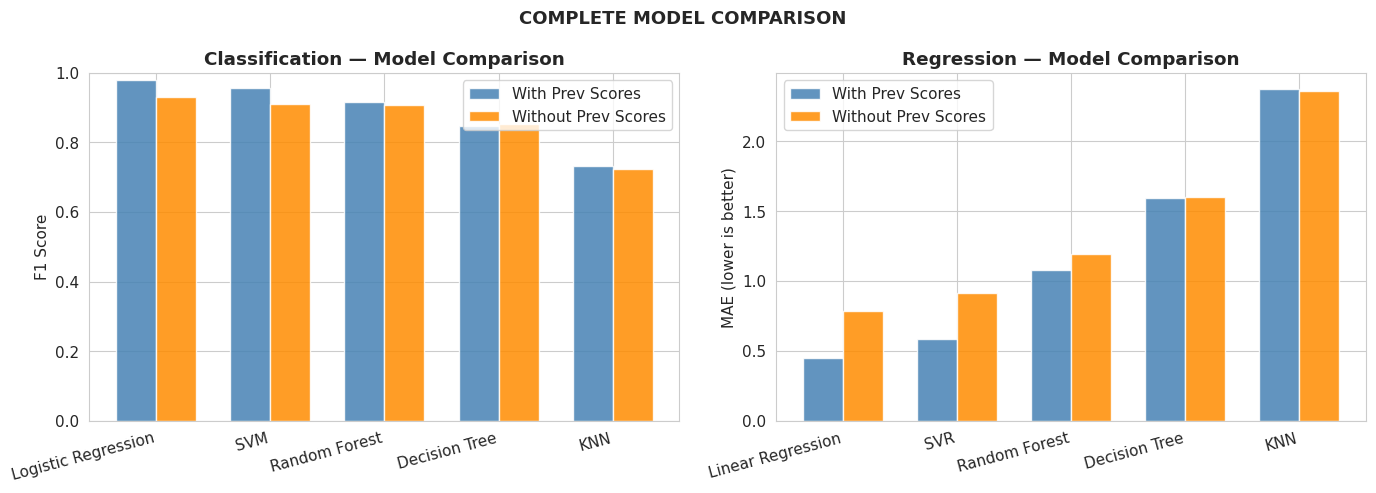

=== Student Performance Predictor ===



IntSlider(value=20, description='Hours Studied:', layout=Layout(width='400px'), max=44, min=1, style=SliderSty…

IntSlider(value=80, description='Attendance (%):', layout=Layout(width='400px'), min=60, style=SliderStyle(des…

IntSlider(value=70, description='Previous Score:', layout=Layout(width='400px'), min=50, style=SliderStyle(des…

IntSlider(value=7, description='Sleep Hours:', layout=Layout(width='400px'), max=10, min=4, style=SliderStyle(…

...

Dropdown(description='Learning Disability:', options=(('No', 0), ('Yes', 1)), style=DescriptionStyle(descripti…

Dropdown(description='School Type:', options=(('Public', 0), ('Private', 1)), style=DescriptionStyle(descripti…

Dropdown(description='Peer Influence:', options=(('Positive', 'positive'), ('Neutral', 'neutral'), ('Negative'…

Button(button_style='success', description='Predict Score', layout=Layout(height='40px', width='200px'), style…

Output()

In [ ]:
# ================================================================
# STEP 10: FINAL COMPARISON CHART + LIVE PREDICTOR
# ================================================================

print("STEP 10: FINAL COMPARISON CHART")
print("=" * 50)

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Classification comparison ---
models_cls = df_results1['Model'].tolist()
f1_with    = df_results1.set_index('Model')['Test F1']
f1_without = df_results2.set_index('Model')['Test F1']

x = np.arange(len(models_cls))
w = 0.35
axes[0].bar(x - w/2, [f1_with.get(m, 0)    for m in models_cls],
            w, label='With Prev Scores',    color='steelblue',  alpha=0.85)
axes[0].bar(x + w/2, [f1_without.get(m, 0) for m in models_cls],
            w, label='Without Prev Scores', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_cls, rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Classification — Model Comparison', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# --- Regression comparison ---
models_reg  = df_reg1['Model'].tolist()
mae_with    = df_reg1.set_index('Model')['Test MAE']
mae_without = df_reg2.set_index('Model')['Test MAE']

x2 = np.arange(len(models_reg))
axes[1].bar(x2 - w/2, [mae_with.get(m, 0)    for m in models_reg],
            w, label='With Prev Scores',    color='steelblue',  alpha=0.85)
axes[1].bar(x2 + w/2, [mae_without.get(m, 0) for m in models_reg],
            w, label='Without Prev Scores', color='darkorange', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(models_reg, rotation=15, ha='right')
axes[1].set_ylabel('MAE (lower is better)')
axes[1].set_title('Regression — Model Comparison', fontweight='bold')
axes[1].legend()

plt.suptitle('COMPLETE MODEL COMPARISON', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# STEP 11: WIDGET-BASED LIVE PREDICTOR
# ================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# Sliders
hours_studied   = widgets.IntSlider(value=20, min=1,  max=44,  step=1,
                  description='Hours Studied:',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

attendance      = widgets.IntSlider(value=80, min=60, max=100, step=1,
                  description='Attendance (%):',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

previous_scores = widgets.IntSlider(value=70, min=50, max=100, step=1,
                  description='Previous Score:',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

sleep_hours     = widgets.IntSlider(value=7,  min=4,  max=10,  step=1,
                  description='Sleep Hours:',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

tutoring        = widgets.IntSlider(value=1,  min=0,  max=8,   step=1,
                  description='Tutoring Sessions:',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

physical        = widgets.IntSlider(value=3,  min=1,  max=6,   step=1,
                  description='Physical Activity:',
                  style={'description_width': 'initial'},
                  layout=widgets.Layout(width='400px'))

# Dropdowns
motivation  = widgets.Dropdown(
              options=[('Low',0),('Medium',1),('High',2)],
              value=1, description='Motivation:',
              style={'description_width': 'initial'})

parental    = widgets.Dropdown(
              options=[('Low',0),('Medium',1),('High',2)],
              value=1, description='Parental Involvement:',
              style={'description_width': 'initial'})

resources   = widgets.Dropdown(
              options=[('Low',0),('Medium',1),('High',2)],
              value=1, description='Access to Resources:',
              style={'description_width': 'initial'})

family_inc  = widgets.Dropdown(
              options=[('Low',0),('Medium',1),('High',2)],
              value=1, description='Family Income:',
              style={'description_width': 'initial'})

teach_qual  = widgets.Dropdown(
              options=[('Low',0),('Medium',1),('High',2)],
              value=1, description='Teacher Quality:',
              style={'description_width': 'initial'})

par_edu     = widgets.Dropdown(
              options=[('High School',0),('College',1),('Postgraduate',2)],
              value=1, description='Parental Education:',
              style={'description_width': 'initial'})

distance    = widgets.Dropdown(
              options=[('Near',0),('Moderate',1),('Far',2)],
              value=0, description='Distance from Home:',
              style={'description_width': 'initial'})

internet    = widgets.Dropdown(
              options=[('Yes',1),('No',0)],
              value=1, description='Internet Access:',
              style={'description_width': 'initial'})

extracurr   = widgets.Dropdown(
              options=[('Yes',1),('No',0)],
              value=1, description='Extracurricular:',
              style={'description_width': 'initial'})

disability  = widgets.Dropdown(
              options=[('No',0),('Yes',1)],
              value=0, description='Learning Disability:',
              style={'description_width': 'initial'})

school_type = widgets.Dropdown(
              options=[('Public',0),('Private',1)],
              value=0, description='School Type:',
              style={'description_width': 'initial'})

peer        = widgets.Dropdown(
              options=[('Positive','positive'),
                       ('Neutral','neutral'),
                       ('Negative','negative')],
              value='positive', description='Peer Influence:',
              style={'description_width': 'initial'})

# Button and output
button = widgets.Button(
         description='Predict Score',
         button_style='success',
         layout=widgets.Layout(width='200px', height='40px'))

output = widgets.Output()

# Predict function
def on_predict(b):
    with output:
        clear_output()

        # Scale numerical inputs
        num_input  = np.array([[hours_studied.value,
                                attendance.value,
                                sleep_hours.value,
                                previous_scores.value,
                                tutoring.value,
                                physical.value]])
        num_scaled = scaler.transform(num_input)[0]
        hours_s, att_s, sleep_s, prev_s, tut_s, phys_s = num_scaled

        # Peer influence
        peer_neg = 1 if peer.value == 'negative' else 0
        peer_pos = 1 if peer.value == 'positive' else 0

        # Cluster
        cluster_input = np.array([[hours_s, att_s,
                                    motivation.value,
                                    prev_s, tut_s, sleep_s]])
        cluster_id    = int(kmeans.predict(cluster_input)[0])
        risk_encoded  = risk_map.get(cluster_id, 1)

        # Build feature row
        feature_row = {
            'Hours_Studied'             : hours_s,
            'Attendance'                : att_s,
            'Parental_Involvement'      : parental.value,
            'Access_to_Resources'       : resources.value,
            'Extracurricular_Activities': extracurr.value,
            'Sleep_Hours'               : sleep_s,
            'Previous_Scores'           : prev_s,
            'Motivation_Level'          : motivation.value,
            'Internet_Access'           : internet.value,
            'Tutoring_Sessions'         : tut_s,
            'Family_Income'             : family_inc.value,
            'Teacher_Quality'           : teach_qual.value,
            'Physical_Activity'         : phys_s,
            'Learning_Disabilities'     : disability.value,
            'Parental_Education_Level'  : par_edu.value,
            'Distance_from_Home'        : distance.value,
            'Peer_Negative'             : peer_neg,
            'Peer_Positive'             : peer_pos,
            'Risk_Group_Encoded'        : risk_encoded,
        }

        input_df = pd.DataFrame([feature_row])
        input_df = input_df[X_with_prev.columns]
        input_df = input_df.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Predict
        predicted_score = best_reg_model.predict(input_df)[0]
        predicted_score = round(float(np.clip(predicted_score, 55, 100)), 1)
        cls_pred        = best_model1.predict(input_df)[0]
        cls_prob        = best_model1.predict_proba(input_df)[0][1]

        result      = "PASS " if cls_pred == 1 else "FAIL "
        risk_labels = {0:'Low Risk ', 1:'Medium Risk ', 2:'High Risk '}

        if predicted_score >= 80:
            performance = "Excellent "
        elif predicted_score >= 70:
            performance = "Above Average "
        elif predicted_score >= 65:
            performance = "Average "
        else:
            performance = "Needs Improvement "

        print("=" * 45)
        print("       STUDENT PREDICTION RESULT")
        print("=" * 45)
        print(f"  Predicted Exam Score : {predicted_score} / 100")
        print(f"  Result               : {result}")
        print(f"  Pass Probability     : {cls_prob*100:.1f}%")
        print(f"  Performance Level    : {performance}")
        print(f"  Risk Group           : {risk_labels.get(risk_encoded, 'Unknown')}")
        print("=" * 45)

        if cls_pred == 0:
            print("\n Suggestions to improve:")
            if hours_studied.value  < 20: print("   → Study more hours per week")
            if attendance.value     < 80: print("   → Improve attendance")
            if motivation.value     <  1: print("   → Work on motivation")
            if tutoring.value       ==  0: print("   → Consider tutoring sessions")
            if sleep_hours.value    <  7: print("   → Get more sleep")
        else:
            print("\n Student is on track to pass!")

button.on_click(on_predict)

# Display
print("=== Student Performance Predictor ===\n")
display(
    hours_studied, attendance, previous_scores,
    sleep_hours, tutoring, physical,
    motivation, parental, resources,
    family_inc, teach_qual, par_edu,
    distance, internet, extracurr,
    disability, school_type, peer,
    button, output
)